# Benchmarking – Baseline Simulation Studies:
## 1) Imports and Set-Up:

### 1.1) Imports & Seed-Setting:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


### 1.2) Helper-Functions:

In [ ]:
from pathlib import Path
import json

from benchmarks._artifacts import read_run, read_runtimes
from benchmarks._registry import SCENARIOS
from benchmarks._tables import summarize
from benchmarks.figures import (
    figure_benchmarking_examples,
    figure_benchmarking_results,
    figure_scaling_ari,
    figure_scaling_runtime,
)
from benchmarks.tables import table_metrics, write_all_tables

RESULTS_ROOT = Path("../results/runs")

# Columns worth reading per scenario. The full summarize() frame carries
# seventeen, most of which only matter to the manuscript tables.
SUMMARY_COLUMNS = ["axis_label", "display_name", "ari_mean", "ari_sd", "k_recovery"]


def run_dir(name):
    """Return the widest sweep available for a scenario.

    Run directories are named by configuration hash, so sorting them
    lexically picks an arbitrary one when a scenario has been run at more
    than one scale. Selecting on the manifest's sweep size instead means a
    reduced exploratory run never silently shadows a full one.
    """
    runs = sorted(p for p in (RESULTS_ROOT / name).glob("*/") if p.is_dir())
    if not runs:
        raise FileNotFoundError(
            f"No run for {name!r}. Produce one with: "
            f"python -m benchmarks.run --scenario {name}"
        )

    def sweep_size(rd):
        manifest = json.loads((rd / "manifest.json").read_text())
        return (manifest["n_seeds"], manifest["n_resamples"])

    return max(runs, key=sweep_size)


def load(name):
    """Read the widest available run for a scenario."""
    return read_run(run_dir(name))


def scenario_report(name):
    """Report a scenario's sweep size, then its per-axis summary.

    One row per (axis label, method), computed from the k each method
    selected. This is the same computation behind the manuscript's S2 to S9
    tables, trimmed to the columns worth reading inline.
    """
    rd = run_dir(name)
    manifest = json.loads((rd / "manifest.json").read_text())
    print(
        f"{name}: {manifest['n_seeds']} seeds x {manifest['n_resamples']} resamples "
        f"(run {rd.name})"
    )
    table = summarize(read_run(rd), metrics=table_metrics())
    return table[SUMMARY_COLUMNS]


---

## 2) Default Benchmarks:

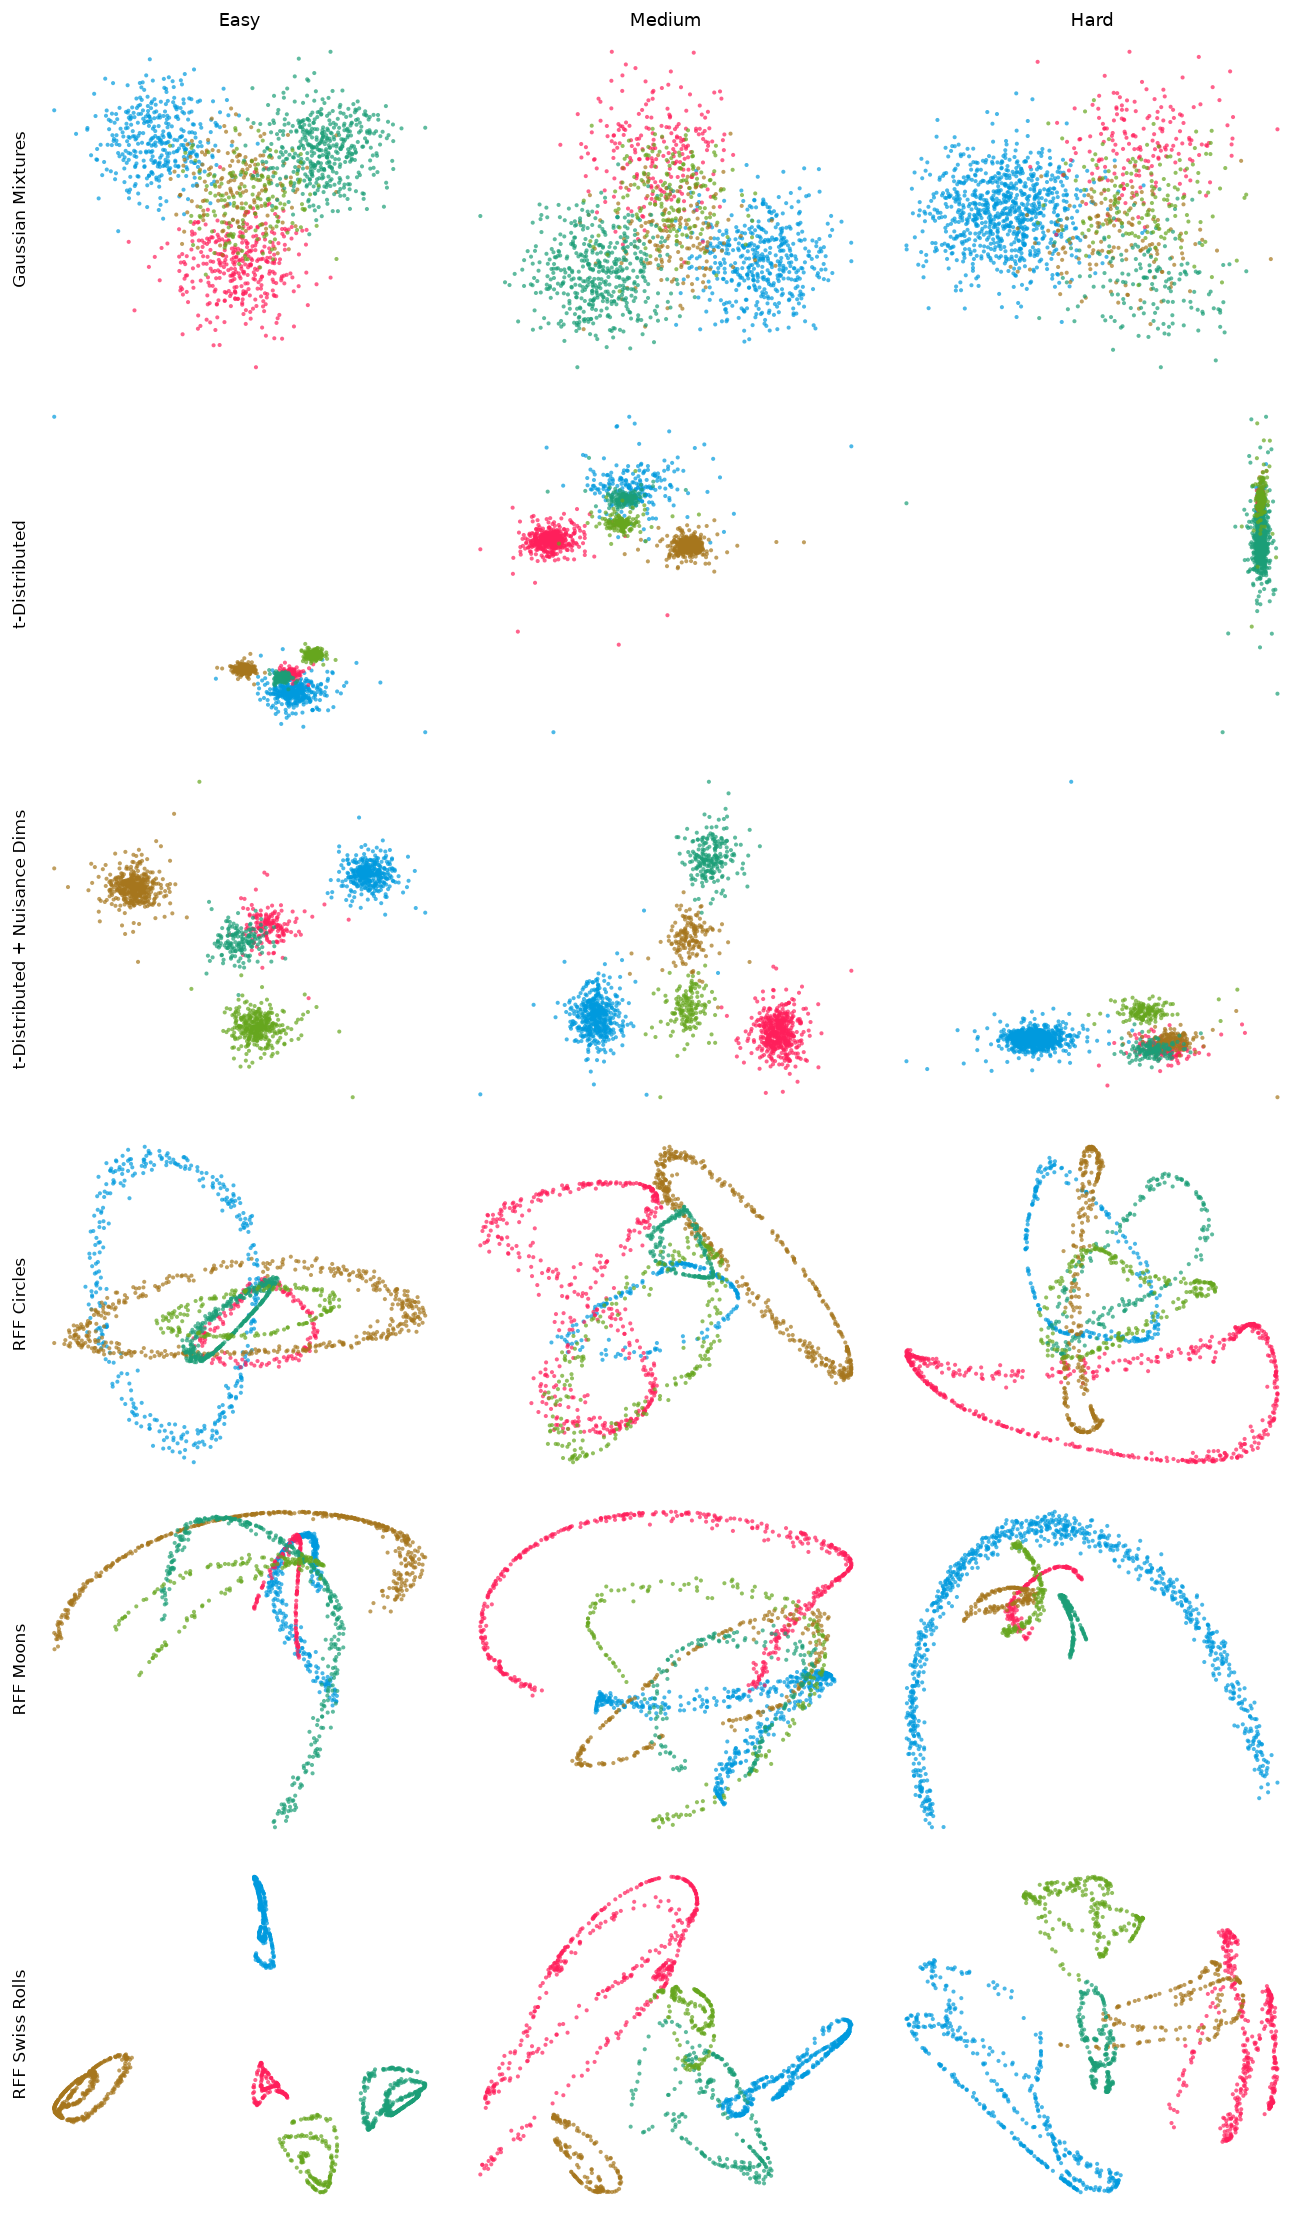

In [4]:
fig = figure_benchmarking_examples()


## 2) Difficulty Scenarios

Each scenario below reports mean ARI at the k its method selected, with the
standard deviation across seeds and the k-recovery rate. Example datasets for all
six appear in the combined figure above.

Compute runs headless. Produce artifacts with `python -m benchmarks.run --all`,
then re-run this notebook, which only reads them.

### 2.1) Gaussian Mixtures:

In [ ]:
scenario_report("gaussians")

### 2.2) t-Distributed Mixtures:

In [ ]:
scenario_report("t_dist")

### 2.3) t-Distributed Mixtures with Noise Dimensions:

In [ ]:
scenario_report("t_dist_noise")

### 2.4) Concentric Circles:

In [ ]:
scenario_report("circles")

### 2.5) Moons:

In [ ]:
scenario_report("moons")

### 2.6) Swiss Rolls:

In [ ]:
scenario_report("swiss_rolls")

---

## 3) Scaling Scenarios

These two sweep an axis other than difficulty, so they carry no example
panel in the combined figure above. Runtime is reported separately in the
scaling figures below.

### 3.1) Gaussian Mixtures over Embedding Dimension:

In [ ]:
scenario_report("gaussians_dimensionality")

### 3.2) Gaussian Mixtures over Sample Size:

In [ ]:
scenario_report("gaussians_samples")

---

## 4) Combined Figures and Manuscript Tables

In [ ]:
results = {name: load(name) for name in SCENARIOS}

fig_main = figure_benchmarking_results(
    {k: v for k, v in results.items() if v["axis_name"].iloc[0] == "difficulty_level"}
)

scaling = {k: v for k, v in results.items() if v["axis_name"].iloc[0] != "difficulty_level"}
fig_ari = figure_scaling_ari(scaling)

runtimes = {name: read_runtimes(run_dir(name)) for name in scaling}
fig_runtime = figure_scaling_runtime(runtimes)

write_all_tables(results, Path("../vis/tables"))


---